# Data Driven Framework for Identifying Key Revenue Drivers and Forecasting Amazon Sales Using Machine Learning

#### Full Scaled Business Intelligence Project

#####  Prepared By:

* Muluwerk Derebe
  

## Objective 

This project focuses on performing analysis on an Amazon Sales dataset to recognize patterns and clean the data by fixing duplicates and inconsistincies.  This is not a real-world dataset, it is a simulated one created and posted on Kaggle, but it is meant to represent how working on a real sales dataset would turn out and can be good training for doing a real one later on in the workforce. It contains 100000 rows, so there is enough to work with. 

I must clean the data to start, and a major problem that needs to be fixed is that some product names don’t match the product category that is listed. It is not feasible to fix all of them, so we must just try and fix as much as we can. One possibility would be to set a formula so that certain keywords in the name change the category, like if “shirt” or “pants” are in the name, change the category to “Clothing”. I could also add an “Other” option to the categories for products with an odd name where it isn’t clear what category it is.  

My key target variable is the Total Amount for the orders, which we can add across rows to show the total revenue by time, location, or product category. We can also track the total number of orders rather than the revenue, or which category is the most popular in a certain location/time period. I will make multiple visualizations to demonstrate how it all connects. 

Finally, I will perform regression to make predictions for the total amount based on all of the other features.
 

## Methodology 

### Data Collection and Preparation 

 Amazon revenue data comprising sales transactions, product categories with brands, pricing, Shipping Cost, and temporal variables will import into Python for preprocessing. 
* [Data Source Link](https://www.kaggle.com/datasets/rohiteng/amazon-sales-dataset)
* [PowerBI Link](https://app.powerbi.com/groups/me/reports/463714e1-7ed9-41a6-b2f8-7a6a07256c52/2bba232855135a012ac2?experience=power-bi)

Data cleaning will include handling missing values, removing duplicates, detecting outliers, and standardizing numerical fields. Categorical variables will be encoded using onehot encoding, and new features such as seasonal indicators and lagged revenue variables will be added to support predictive modeling. 

### Exploratory Data Analysis (EDA)

 

  Power BI will be used to describe and visualize the revenue of the Amazon data set. Such as Bar Charts, histogram, line charts, heatmap and other appropriate techniques will be used to create Interactive dashboards that will be used to display revenue trends, category performance, customer behavior, and seasonal patterns. On top of that, Statistical summaries, correlation matrices, and variability analysis to identify key revenue drivers and guide feature selection for machinelearning models

### Importing the libraries and then Loading the dataset

In this initial stage of the project, we set up the foundational environment required for data analysis and exploration. We begin by importing the essential Python libraries that will be used throughout the analysis:

* **Pandas** – for data manipulation, cleaning, and analysis
* **NumPy** – for numerical computations and array operations
* **Matplotlib and Seaborn** – for creating high-quality visualizations and exploratory data analysis (EDA)

Once the libraries are successfully imported, we load the Amazon dataset from a local CSV file into a pandas DataFrame. This dataset will serve as the primary source for all subsequent analysis, including data cleaning, exploratory data analysis, feature engineering, and Machine Learning modeling.
To ensure we can view the data clearly, we adjust pandas display options to remove restrictions on the number of columns and rows shown. Finally, we display a random sample of 5 rows from the dataset using **.sample(5)**, **.head()**, **.tail()** to get an initial look at the structure and content of the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [2]:
df = pd.read_csv(r"C:\Users\muluw\Desktop\BISI\Business Intelligence\Project\Amazon (1).csv")

**Adjust Pandas desply option for better view**

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.sample(5)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
82403,ORD0082404,2021-08-10,CUST041419,Kabir Verma,P00041,Webcam Full HD,Home & Kitchen,Zenith,3,416.08,0.05,0.00,10.19,1196.02,Net Banking,Shipped,Houston,TX,India,SELL01812
79789,ORD0079790,2021-09-08,CUST045149,Vihaan Reddy,P00027,Winter Jacket,Electronics,FitLife,5,249.11,0.05,94.66,11.99,1289.92,Credit Card,Delivered,Dallas,TX,United States,SELL01245
31282,ORD0031283,2020-08-09,CUST013569,Anjali Verma,P00036,Smart Light Bulb,Books,Zenith,2,251.40,0.10,22.63,10.18,485.33,UPI,Delivered,Austin,TX,United States,SELL01748
4151,ORD0004152,2021-09-30,CUST013748,Priya Joshi,P00020,Office Chair,Sports & Outdoors,KiddoFun,5,422.52,0.15,323.23,1.23,2120.17,Credit Card,Shipped,New York,NY,United Kingdom,SELL00094
33216,ORD0033217,2024-10-10,CUST033174,Neha Joshi,P00048,Wireless Charger,Clothing,ReadMore,1,429.91,0.20,27.51,8.03,379.47,UPI,Delivered,Austin,TX,India,SELL01994


In [4]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [5]:
df.tail()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
99995,ORD0099996,2023-03-07,CUST001356,Karan Joshi,P00047,Memory Card 128GB,Electronics,Apex,2,492.34,0.00,78.77,2.75,1066.20,UPI,Delivered,Jacksonville,FL,India,SELL00041
99996,ORD0099997,2021-11-24,CUST031254,Sunita Kapoor,P00046,Car Charger,Sports & Outdoors,Apex,5,449.30,0.00,179.72,6.07,2432.29,Credit Card,Delivered,San Jose,CA,United States,SELL01449
99997,ORD0099998,2023-04-29,CUST012579,Aman Gupta,P00030,Dress Shirt,Sports & Outdoors,BrightLux,4,232.40,0.00,74.37,12.43,1016.40,Cash on Delivery,Delivered,Indianapolis,IN,United States,SELL00028
99998,ORD0099999,2021-11-01,CUST026243,Simran Gupta,P00046,Car Charger,Sports & Outdoors,HomeEase,1,294.05,0.00,23.52,13.09,330.66,Debit Card,Delivered,Charlotte,NC,United States,SELL00324
99999,ORD0100000,2021-12-04,CUST029492,Sunita Reddy,P00019,LED Desk Lamp,Home & Kitchen,CoreTech,5,166.70,0.05,63.35,3.34,858.52,Debit Card,Delivered,New York,NY,United States,SELL00761


**Insights:** The dataset preview confirms successful loading of a large, transaction‑level retail dataset containing customer, product, pricing, and order‑level attributes.
Initial inspection using random samples, head, and tail outputs verifies data completeness, consistency, and readiness for preprocessing.
These foundational checks ensure the dataset is suitable for downstream machine‑learning tasks such as demand forecasting, customer segmentation, or sales prediction.

#### Dataset Dimensions Overview

In [6]:
df.shape #Giving the amount of rows() and columns

(100000, 20)

* The dataset contains 100,000 rows and 20 columns, confirming a large, rich structure suitable for future exploratory data analysis, feature selection, and machine‑learning modeling.

#### Check the Column with their data types and Missing data values
As part of the initial data‑quality assessment, we used **.info()** to examine the structure(**dtypes**), completeness(**.isnull().sum()**), and data types of the dataset. This step is essential in my project workflow because it validates whether the data is suitable for preprocessing, feature engineering, and model development in our future Machine learning modelling.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

**Insights:** I have confirmed there are no null records. The dataset contains 100,000 fully populated records across 20 fields, with no missing values detected. A mix of numerical and categorical features provides a strong foundation for building predictive ML models such as sales forecasting, customer segmentation, or order‑status classification.

### Descriptive Statistical Analysis for Machine Learning Readiness
- To understand the distribution and behavior of key numerical features, We generated descriptive statistics using **.describe()**.
- This step provides essential insights into central tendencies, variability, and potential outliers across pricing, quantity, and transaction‑level metrics. Such statistical profiling enables us to ensures the dataset is well‑understood before applying transformations, feature engineering, or machine‑learning algorithms.


In [9]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [10]:
df.describe(include='object')

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,PaymentMethod,OrderStatus,City,State,Country,SellerID
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,1825,43233,200,50,50,6,10,6,5,20,13,5,1999
top,ORD0000001,2022-04-28,CUST023748,Karan Joshi,P00019,LED Desk Lamp,Electronics,ReadMore,Credit Card,Delivered,Charlotte,TX,United States,SELL01099
freq,1,85,10,556,2098,2098,16853,10204,35038,74628,5110,24896,70058,78


**Insights:** The numerical features show consistent ranges and well‑defined quartiles, indicating stable transaction patterns across the dataset.
High variability in fields like UnitPrice, Tax, and TotalAmount suggests strong potential for predictive modeling and segmentation.
Categorical summaries reveal rich diversity across customers, products, brands, and locations are ideal for building ML models that leverage behavioral and demographic patterns.




### Duplicate Record Validation
* To ensure data integrity before modeling, we checked for duplicate entries using key identifiers such as OrderID and ProductID.
* This validation step helps confirm that no repeated transactions distort patterns or bias machine‑learning outcomes.

In [11]:
duplicates = df.duplicated(subset=['OrderID', 'ProductID'], keep=False)
print(df[duplicates])

Empty DataFrame
Columns: [OrderID, OrderDate, CustomerID, CustomerName, ProductID, ProductName, Category, Brand, Quantity, UnitPrice, Discount, Tax, ShippingCost, TotalAmount, PaymentMethod, OrderStatus, City, State, Country, SellerID]
Index: []


**Insights:** 
* The duplicate check returned an empty DataFrame, indicating that no repeated records exist for the selected identifiers.
* This confirms the dataset maintains unique transaction entries, strengthening its reliability for downstream analysis.
* With duplicates ruled out, the data is clean and ready for feature engineering and model development.

### Study area (Looking at the countries that are available in our dataset)

In [12]:
df['Country'].unique()

array(['India', 'United States', 'Canada', 'Australia', 'United Kingdom'],
      dtype=object)

**insights:** 
* The dataset includes transactions from five countries, they are India, United States, Canada, Australia, and the United Kingdom.
* so, the dataset showing a diverse geographic spread.
* This multi‑country coverage enables richer comparative analysis across regions and supports more generalizable machine‑learning models.
Such geographic variety also helps uncover country‑specific purchasing patterns, customer behaviors, and market trends.


#### Declaring Revenue(Study Target Variable)

In [13]:
df['Revenue'] = df['TotalAmount']

<h2> Visualizations </h2>

Now I will go over some visualizations based on our data and how other features are tied to revenue

### Distribution of Revenue

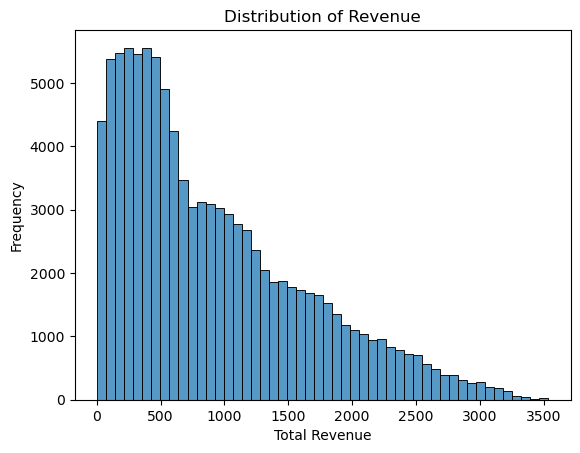

In [14]:
plt.figure()
sns.histplot(df['Revenue'], bins=50)
plt.title('Distribution of Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.show()

**Insight :**
* Revenue is heavily right‑skewed, indicating that most transactions are low‑value while a small number of high‑value sales stretch the upper tail.
* The concentration of values near the lower end suggests potential outliers or high‑impact customers that may require separate segmentation or feature scaling during modeling.

### Revenue by Product Category

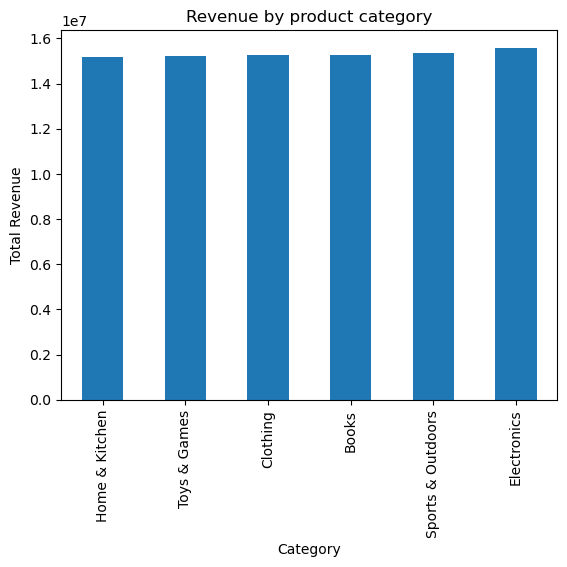

In [15]:
df.groupby('Category')['Revenue'].sum().sort_values().plot(kind='bar')
plt.title('Revenue by product category')
plt.ylabel('Total Revenue')
plt.show()

**Insight :**
* Revenue is distributed fairly evenly across categories, suggesting no single product line dominates overall sales—useful for balanced modeling without heavy category bias.
* The similar revenue levels across categories indicate that category‑based features may require additional engineering (e.g., interaction terms, average order value, customer segments) to reveal meaningful predictive power.
* However, there is a problem where many rows have product names are not consistent with the product category, and we must do some data cleaning to fix this issue. More will be provided below.


In this function below, REGEX is used to search for keywords in the product name to reassign the category depending on what it is to fix the inconsistencies. Dozens of keywords are used and a new category called "Other" has been created for products that don't have a keyword that neatly fits in. Otherwise, all of the categories are the same.

In [10]:
import re

def fix_category(product_name):
    name = str(product_name).lower()

    if re.search(
        r'shirt|tshirt|t-shirt|tee|tank top|pants|jeans|jacket|coat|dress|'
        r'sweater|hoodie|sweatshirt|socks|gloves|scarf|hat|cap|beanie|'
        r'shorts|skirt|blouse|suit|tie|belt|shoes|sneakers|boots|sandals|'
        r'heels|flip flops|underwear|bra|lingerie|glasses|sunglasses|'
        r'clothing|apparel|outerwear|activewear|sportswear',
        name
    ):
        return 'Clothing'
        
    elif re.search(
        r'phone|smartphone|iphone|android|laptop|notebook|macbook|camera|'
        r'dslr|computer|pc|desktop|monitor|tablet|ipad|drone|microphone|'
        r'mic|mouse|keyboard|webcam|headphone|earbuds|airpods|speaker|'
        r'soundbar|power bank|charger|charging cable|usb cable|adapter|'
        r'router|modem|tv|television|projector|console|gpu|graphics card|cpu|processor|ssd|hard drive|'
        r'memory card|usb drive|bluetooth|smartwatch|fitness tracker',
        name
    ):
        return 'Electronics'

    elif re.search(
        r'kitchen|microwave|oven|dish|blender|fridge|refrigerator|cookware|'
        r'fork|spoon|knife|cutlery|plate|bowl|cup|mug|toaster|kettle|'
        r'coffee maker|espresso|vacuum|cleaner|mop|broom|sofa|couch|chair|'
        r'table|desk|lamp|light|pillow|blanket|mattress|curtain|rug|'
        r'storage|organizer|decor|decoration|frame|mirror|bed|dresser|'
        r'pan|pot|air fryer|slow cooker|rice cooker|dish rack|laundry|'
        r'garbage can|trash bin|humidifier|dehumidifier|fan|heater',
        name
    ):
        return 'Home & Kitchen'

    elif re.search(
        r'book|novel|comic|magazine|manga|textbook|journal|notebook|'
        r'paperback|hardcover|biography|manual|guide|workbook',
        name
    ):
        return 'Books'

    elif re.search(
        r'ball|water bottle|yoga|weight|dumbbell|barbell|lift|sport|'
        r'fitness|exercise|treadmill|bike|bicycle|helmet|skate|ski|'
        r'camping|tent|hiking|outdoor|kayak|fishing|golf|basketball|'
        r'soccer|football|baseball|tennis|volleyball|resistance band|'
        r'jump rope|boxing|punching bag',
        name
    ):
        return 'Sports and Outdoors'

    elif re.search(
        r'toy|doll|game|board game|puzzle|lego|action figure|'
        r'plush|stuffed animal|rc car|remote control|kids toy|'
        r'children toy|playset|building blocks',
        name
    ):
        return 'Toys and Games'

    else:
        return 'Other'

In [11]:
df['Category_EDA'] = df['ProductName'].apply(fix_category)

Once that is done, we can use our newly assigned cleaned version of the product category to create a new visualization that more accurately represents the revenue by different product categories. Electronics easily dominates the list with 44 million dollars in revenue, while books are the lowest with 3.5 million.

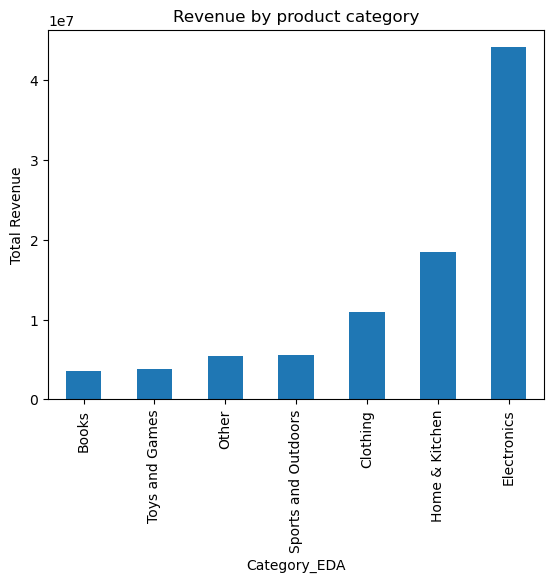

In [12]:
df.groupby('Category_EDA')['TotalAmount'].sum().sort_values().plot(kind='bar')

plt.title('Revenue by product category')
plt.ylabel('Total Revenue')
plt.show()

In [13]:
revenue_by_category = df.groupby('Category_EDA')['TotalAmount'].sum().sort_values()
print(revenue_by_category)

Category_EDA
Books                   3541167.14
Toys and Games          3754393.39
Other                   5383935.72
Sports and Outdoors     5527515.54
Clothing               10990035.74
Home & Kitchen         18487566.03
Electronics            44141034.36
Name: TotalAmount, dtype: float64


### Country‑Level Revenue Patterns and Outlier Behavior

C:\Users\acman\AppData\Local\Temp\ipykernel_6352\4149044702.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Country', x='Revenue', data=df, palette='viridis')


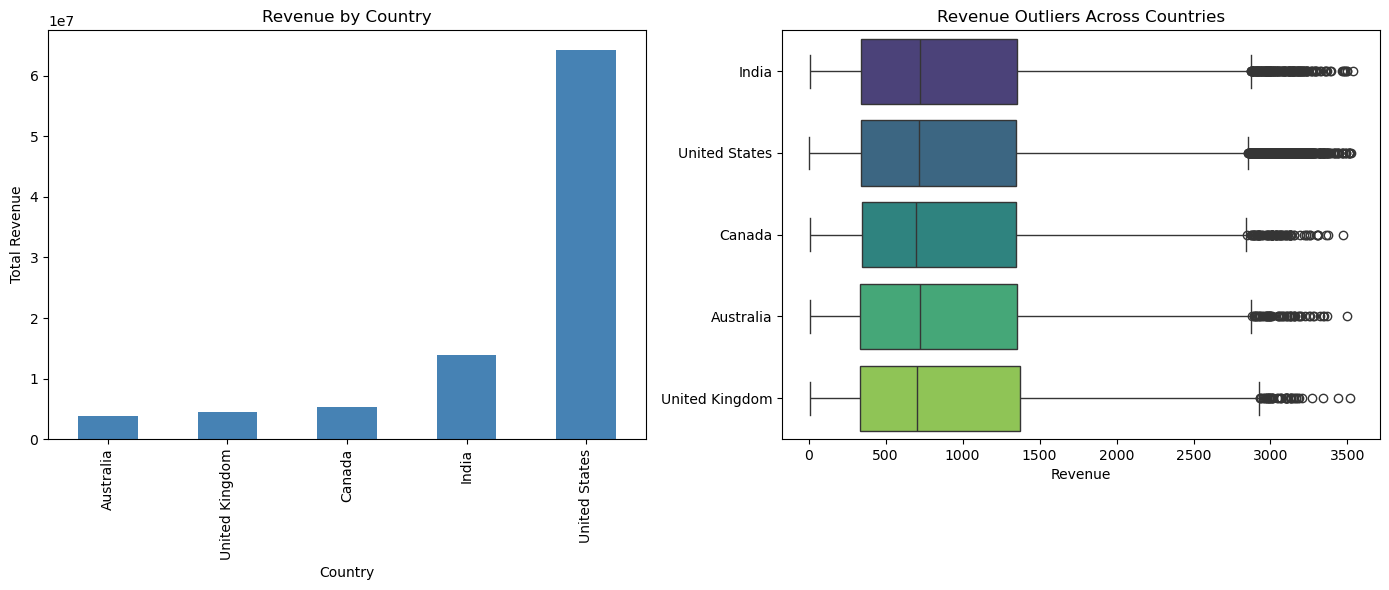

Country
Australia          3789106.44
United Kingdom     4526896.86
Canada             5323757.00
India             13875839.12
United States     64310048.50
Name: Revenue, dtype: float64


In [9]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
df.groupby('Country')['Revenue'].sum().sort_values().plot(kind='bar', color='steelblue')
plt.title('Revenue by Country')
plt.ylabel('Total Revenue')
plt.xlabel('Country')

plt.subplot(1, 2, 2)
sns.boxplot(y='Country', x='Revenue', data=df, palette='viridis')
plt.title('Revenue Outliers Across Countries')
plt.xlabel('Revenue')
plt.ylabel('')
plt.tight_layout()
plt.show()

revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values()
print(revenue_by_country)

**Insights :**
* Strong Geographic Imbalance in Revenue Contribution
* The United States generates far more revenue than any other country, creating a dominant market segment.
* This imbalance means country‑based features may need normalization or weighting to prevent the model from overfitting to U.S. patterns.

* High‑Value Outliers Concentrated in the U.S. and India
* The boxplot shows that the United States and India contain numerous extreme revenue values, indicating high‑spending customers or large‑order events.
* These outliers may require special handling (log transforms, winsorization, or separate segmentation) to stabilize model training.

* Stable Revenue Distributions in Smaller Markets
Countries like Australia, the UK, and Canada show tighter, more consistent revenue ranges, suggesting predictable purchasing behavior.
* These stable distributions can improve model reliability and may benefit from country‑specific feature engineering.
  
**Generally speaking**

* The United States generates over $64M$ in revenue, far surpassing all other countries. This dominant contribution means U.S. transactions will heavily influence model patterns unless features are normalized or country effects are controlled.
* Countries like Australia ($4.5M$), and Canada ($5.3M$) contribute substantially less revenue, indicating strong geographic imbalance. This makes country a high‑value categorical feature, and engineering region‑specific indicators or scaling strategies may improve model fairness and predictive accuracy.

### Revenue Distribution and Outlier Patterns Across Brands

C:\Users\muluw\AppData\Local\Temp\ipykernel_8108\1943335099.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Brand', x='Revenue', data=df, palette='viridis')


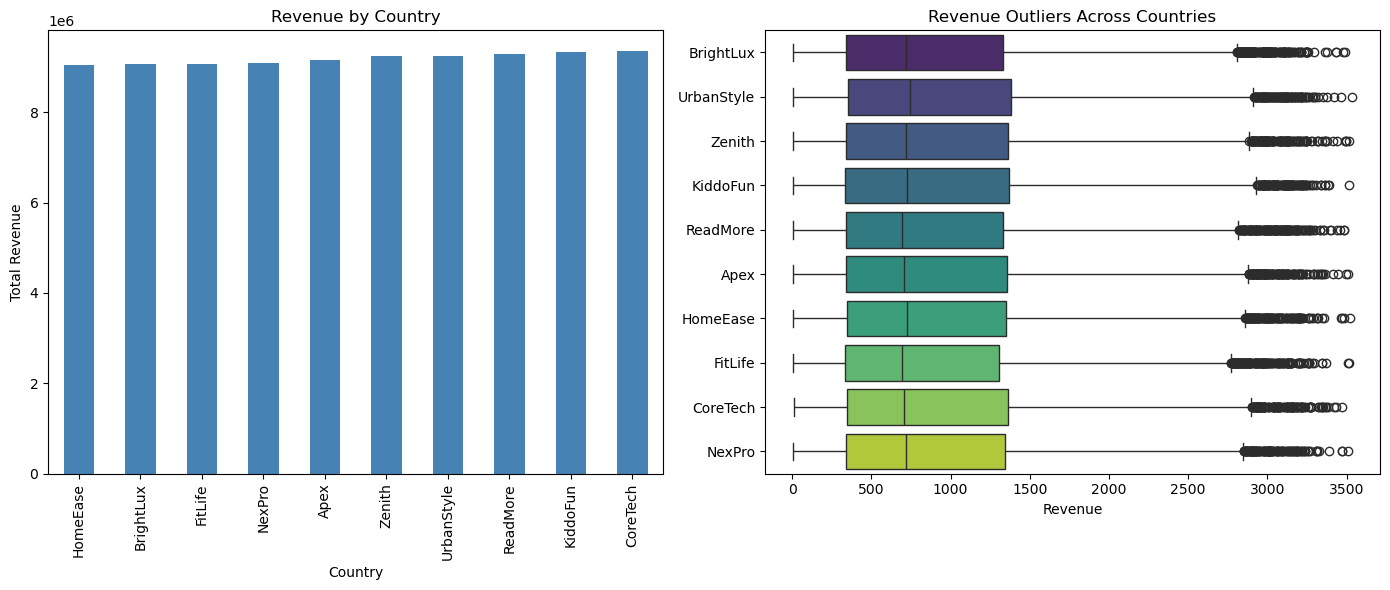

Brand
HomeEase      9045092.83
BrightLux     9056816.11
FitLife       9061444.68
NexPro        9078824.97
Apex          9147604.72
Zenith        9239960.39
UrbanStyle    9249027.45
ReadMore      9278406.63
KiddoFun      9324749.55
CoreTech      9343720.59
Name: Revenue, dtype: float64


In [96]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
df.groupby('Brand')['Revenue'].sum().sort_values().plot(kind='bar', color='steelblue')
plt.title('Revenue by Country')
plt.ylabel('Total Revenue')
plt.xlabel('Country')

plt.subplot(1, 2, 2)
sns.boxplot(y='Brand', x='Revenue', data=df, palette='viridis')
plt.title('Revenue Outliers Across Countries')
plt.xlabel('Revenue')
plt.ylabel('')
plt.tight_layout()
plt.show()

revenue_by_country = df.groupby('Brand')['Revenue'].sum().sort_values()
print(revenue_by_country)

**Insight 1**
* Brands Show Very Similar Total Revenue Levels
* All brands fall within a narrow revenue range (~$9.0M–$9.3M), indicating that brand alone is not a strong differentiator. For ML, this means Brand * may require interaction features (Brand × Category, Brand × Country) to reveal meaningful predictive value.

**Insight 2**
* Outlier Behavior Varies Across Brands
* The boxplot shows that some brands exhibit more extreme revenue values than others, suggesting differences in customer spending patterns or product mix.
* These outliers may influence model training and could benefit from log transforms or winsorization during feature engineering.

**Insight 3**
* Subtle Revenue Differences May Reflect Customer Preference Trends
* Brands like CoreTech, KiddoFun, and ReadMore sit slightly higher in total revenue, hinting at stronger customer engagement or higher‑value product lines.
* These subtle variations can be leveraged for brand ranking features or customer segmentation in your ML pipeline.

### Revenue Patterns by Payment Method and Order Status

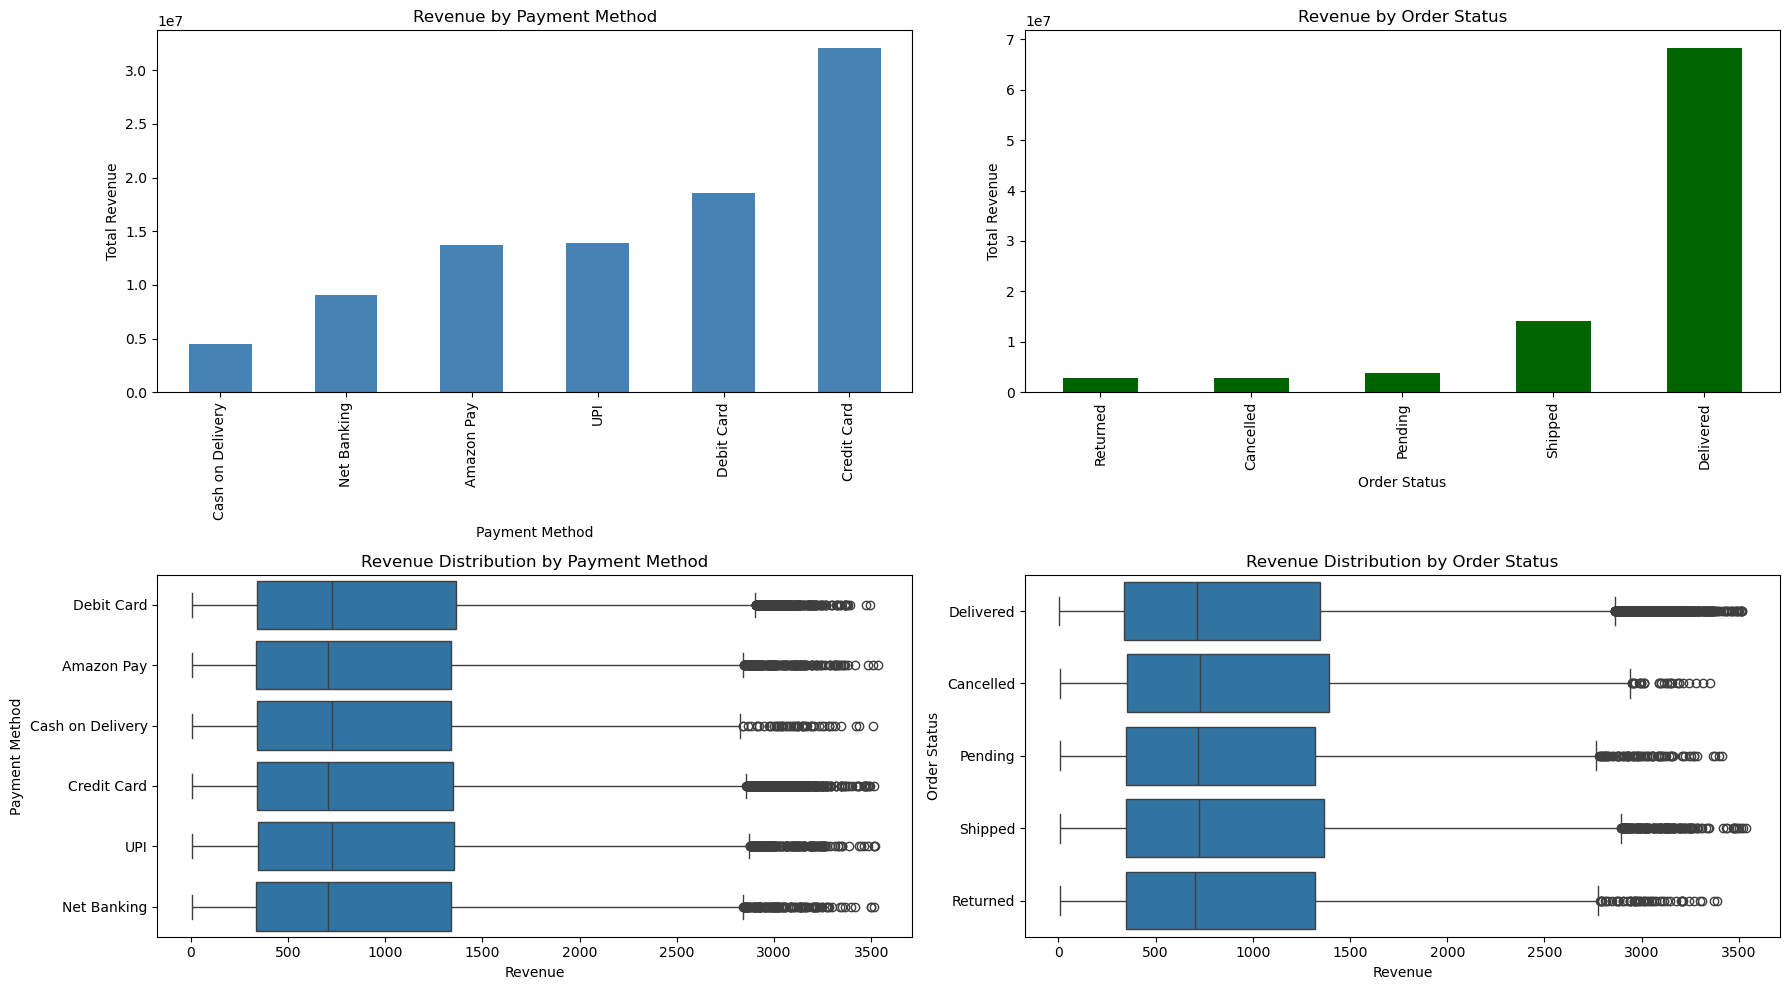


=== Revenue by Payment Method ===
PaymentMethod
Cash on Delivery     4515609.16
Net Banking          9055674.57
Amazon Pay          13697498.42
UPI                 13896028.55
Debit Card          18538678.53
Credit Card         32122158.69
Name: Revenue, dtype: float64

=== Revenue by Order Status ===
OrderStatus
Returned      2780662.46
Cancelled     2851122.39
Pending       3737556.98
Shipped      14083628.99
Delivered    68372677.10
Name: Revenue, dtype: float64


In [97]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
df.groupby('PaymentMethod')['Revenue'].sum().sort_values().plot(
    kind='bar', color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Revenue by Payment Method')
axes[0, 0].set_ylabel('Total Revenue')
axes[0, 0].set_xlabel('Payment Method')
df.groupby('OrderStatus')['Revenue'].sum().sort_values().plot(
    kind='bar', color='darkgreen', ax=axes[0, 1])
axes[0, 1].set_title('Revenue by Order Status')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].set_xlabel('Order Status')

sns.boxplot(x='Revenue', y='PaymentMethod', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Revenue Distribution by Payment Method')
axes[1, 0].set_xlabel('Revenue')
axes[1, 0].set_ylabel('Payment Method')

sns.boxplot(x='Revenue', y='OrderStatus', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Revenue Distribution by Order Status')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Order Status')

plt.tight_layout()
plt.show()

print("\n=== Revenue by Payment Method ===")
payment_table = df.groupby('PaymentMethod')['Revenue'].sum().sort_values()
print(payment_table)

print("\n=== Revenue by Order Status ===")
orderstatus_table = df.groupby('OrderStatus')['Revenue'].sum().sort_values()
print(orderstatus_table)

**Insight 1**
* Credit Card Dominates Revenue Contribution
* Credit Card payments generate $32.1M, far exceeding all other methods. 
* This strong concentration suggests that payment method is a high‑value categorical feature and may influence customer segmentation or spending‑behavior modeling.

**Insight 2** 
* Cash on Delivery Shows the Lowest Revenue
* Cash on Delivery contributes only $4.5M, indicating lower adoption and potentially lower‑value customers. 
* This imbalance may require encoding strategies to prevent the model from under‑learning minority payment behaviors.

**Insight 3**
* Delivered Orders Drive the Majority of Revenue
* Delivered orders account for $68.3M, dwarfing all other statuses. 
* This highlights that successful order completion is the primary revenue driver and may be a key target for operational optimization or predictive modeling.
  
**Insight 4**
* Returned and Cancelled Orders Represent Revenue Risk
* Returned ($2.78M$), and Cancelled ($2.85M) orders show significantly lower revenue, indicating potential loss points.
* These categories can be engineered into binary success/failure features to improve churn or refund prediction models.

**Insight 5** 
* High‑Value Outliers Concentrated in Digital Payments and Successfully deliverd Orders.
* Both boxplots show that Credit Card, Debit Card, and UPI transactions contain noticeably higher outliers compared to other payment methods, indicating that high‑spending customers prefer digital channels.
* Similarly, Delivered and Shipped orders show more extreme revenue values than Cancelled or Returned orders. These outliers may represent premium purchases or bulk orders, and handling them carefully (log transforms, winsorization, or segmentation) can significantly improve model stability and predictive accuracy.

## Top 10 Most Frequently Sold Products

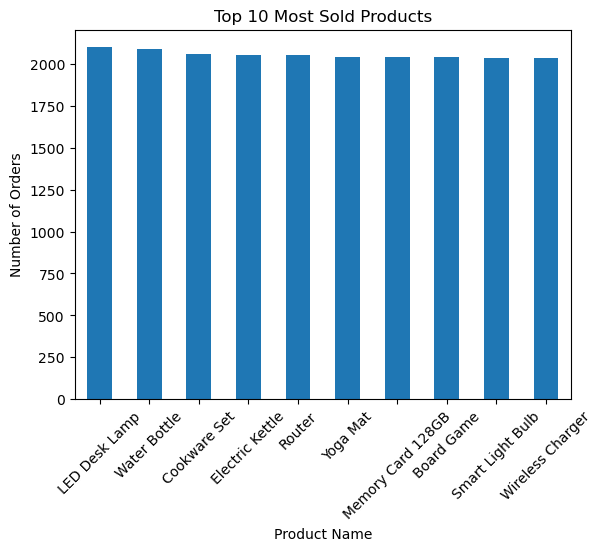

ProductName
LED Desk Lamp        2098
Water Bottle         2088
Cookware Set         2058
Electric Kettle      2054
Router               2054
Yoga Mat             2041
Memory Card 128GB    2039
Board Game           2039
Smart Light Bulb     2036
Wireless Charger     2034
Name: count, dtype: int64

In [98]:
top_products.head(10).plot(kind='bar')

plt.title('Top 10 Most Sold Products')
plt.xlabel('Product Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

top_products = df['ProductName'].value_counts()
top_products.head(10)

**Insight :**
* The most sold items everyday are , high‑utility products such as LED Desk Lamps (2,098 sales), Water Bottles (2,088), and Cookware Sets (2,058).
* This pattern suggests strong customer demand for practical, frequently used household and lifestyle items has a trend that can inform inventory planning, product bundling, and demand‑forecasting features in your ML pipeline.


# Disribution of continuous features to see if there is outlier effects

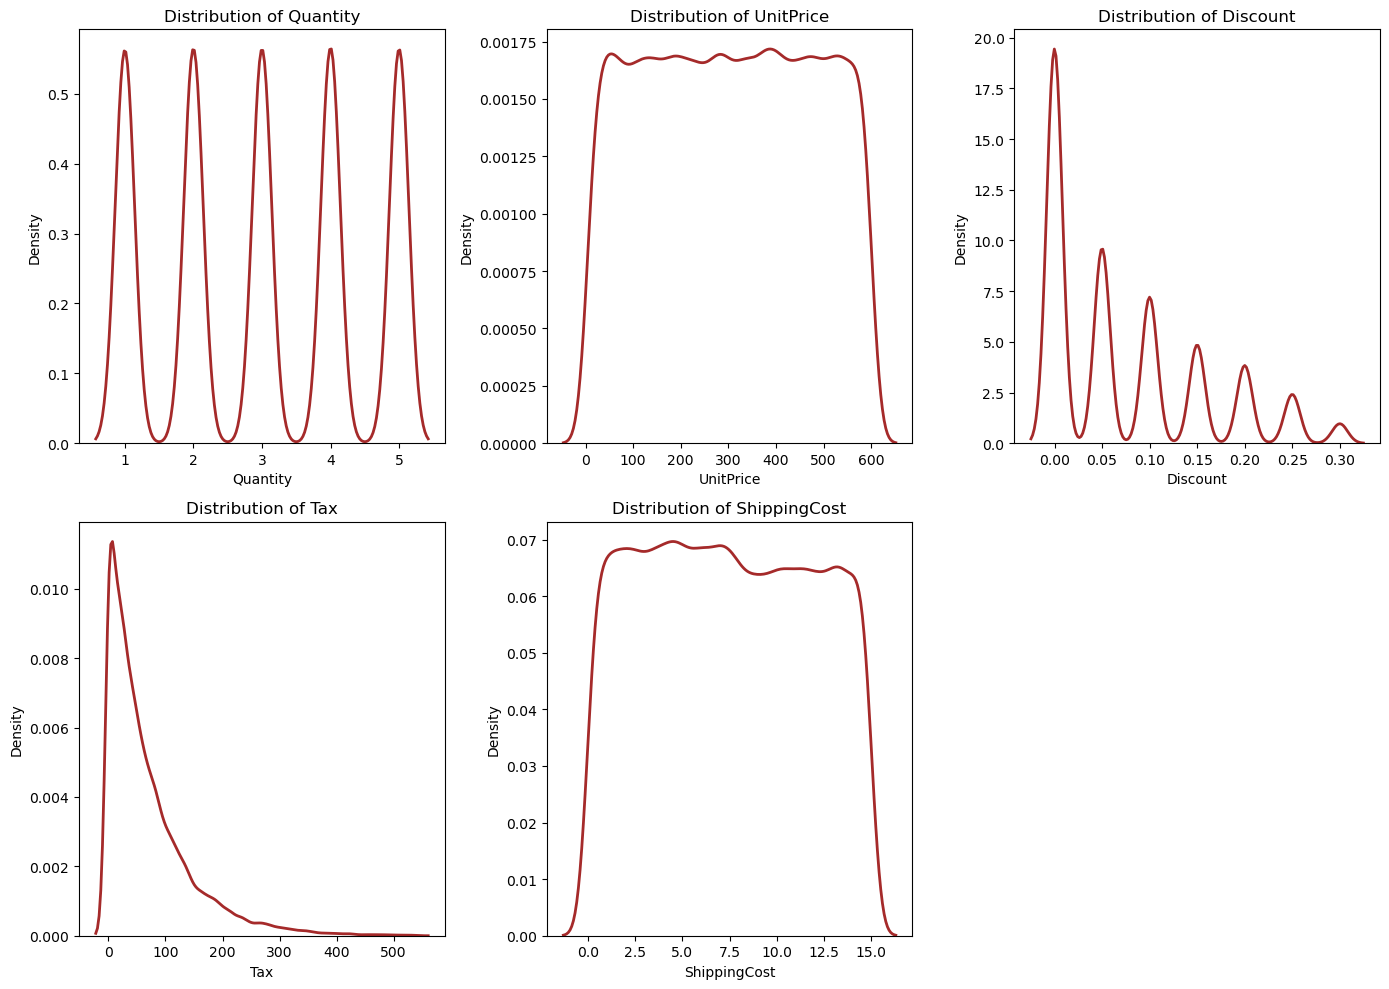

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

continuous_features = ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost']

plt.figure(figsize=(14, 10))

for i, col in enumerate(continuous_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(df[col], fill=False, linewidth=2, color='brown')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

**1. Quantity**
* The distribution is highly discrete, with sharp spikes at specific values.
* This suggests customers tend to buy fixed quantities (e.g., 1, 2, 3 units).
* The density is highest at Quantity = 1, meaning most orders are single‑item purchases.

**Implication:**
* Amazon sales are dominated by small‑quantity transactions, which is typical in retail or e‑commerce based on our dataset.

**2. UnitPrice**
* The curve is very flat, indicating prices are spread across a wide range.
* No strong peak which means no dominant price point.
* Long right tail which means some items are very expensive, but rare.

**Implication:**
* Amazon catalog likely contains a mix of low‑cost and high‑cost items, with no single price dominating based on our dataset.
**3. Discount**
- Strong peak near 0% discount.
- Density drops sharply as discount increases.
- A few small bumps indicate occasional promotions.

**Implication:**
Most transactions occur without discounts, and higher discounts are rare in Amazon Sales.

**4. Tax**
- Very steep decline and right‑skewed distribution.
- Most transactions have low tax amounts.
- A long tail indicates a few transactions with high tax (likely tied to high‑value items).

**Implication:**
Tax is proportional to price, and since most items are inexpensive, tax amounts stay low.
**5. ShippingCost**
- Mostly flat with small variations.
- Indicates shipping costs vary but stay within a narrow range.
- No extreme outliers.

**Implication:**
Shipping pricing is relatively stable — likely based on weight tiers or flat‑rate rules.

**Overall Insight**
In this Amazon dataset, continuous features show a mix of discrete purchasing behavior (Quantity), wide price variability (UnitPrice), and mostly low‑value transactions (Tax, ShippingCost). Discounts are rarely applied, and shipping costs remain stable. These patterns suggest a retail environment where customers buy small quantities at regular prices, with occasional high‑value purchases creating long‑tail effects.

# Correlation Matrix  to identify Multicollinearity between continuous features

* To evaluate relationships among the continuous variables, I generated a correlation matrix and visualized it using a heatmap.
* This step helps identify patterns, dependencies, and potential multicollinearity that could influence model performance.
* Understanding these correlations ensures that feature selection and model design are grounded in the underlying data behavior.

=== Correlation Matrix ===
              Quantity  UnitPrice  Discount     Tax  ShippingCost
Quantity        1.0000     0.0044   -0.0004  0.4379        0.0200
UnitPrice       0.0044     1.0000    0.0062  0.5269        0.0458
Discount       -0.0004     0.0062    1.0000 -0.0776        0.0003
Tax             0.4379     0.5269   -0.0776  1.0000        0.0235
ShippingCost    0.0200     0.0458    0.0003  0.0235        1.0000


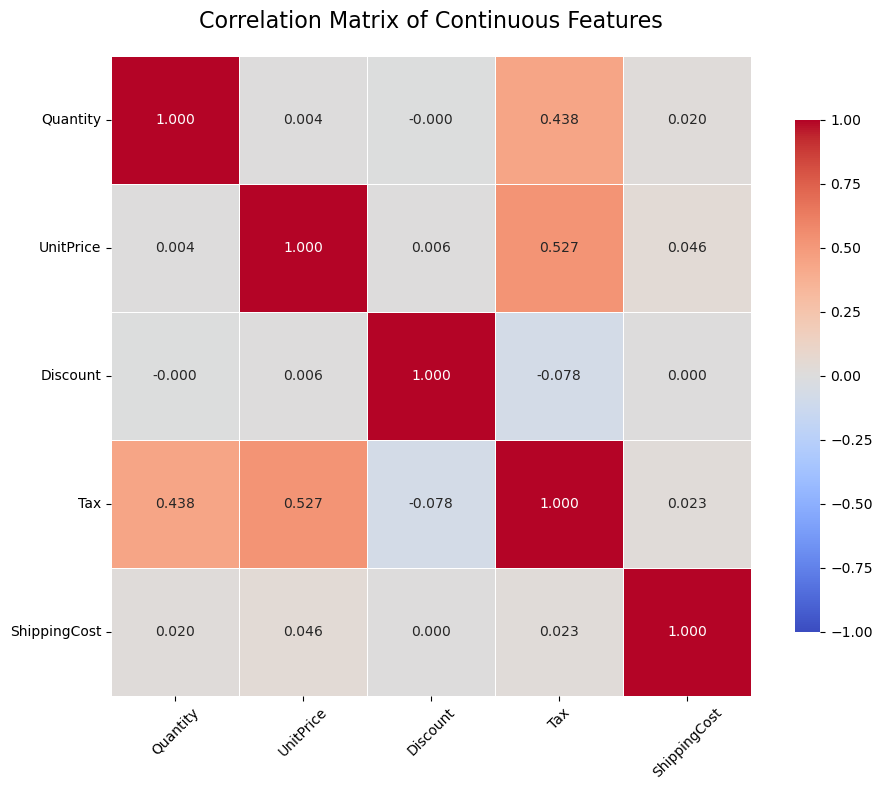

In [100]:
continuous_features = ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost']
corr_matrix = df[continuous_features].corr()
print("=== Correlation Matrix ===")
print(corr_matrix.round(4))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,           # Show numbers inside cells
            fmt='.3f',            # 3 decimal places
            cmap='coolwarm',      # Red-Blue color scheme
            vmin=-1, vmax=1,      # Correlation range
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Continuous Features', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight: 
##### **1. Strongest Correlations (Most Important Observations)**

Tax and UnitPrice (0.527) - Moderate Positive Correlation
This is expected. Higher priced items usually attract higher tax amounts. This is a logical business relationship.
Tax and Quantity (0.438) - Moderate Positive Correlation
When customers buy more units (higher quantity), the total tax also increases.
UnitPrice and Tax (0.527) is the strongest correlation in this matrix.

##### **2. Very Weak / Negligible Correlations**

Quantity vs UnitPrice (0.004) - Almost no correlation
This is good. It means quantity purchased doesn't strongly depend on the price of the item.
Discount vs all other features  Very low correlations (near zero)
Discount appears to be applied quite independently of quantity, unit price, tax, or shipping cost.
ShippingCost vs others - All correlations are very low (< 0.05)
Shipping cost seems mostly independent of the other variables. This is generally desirable.

##### **3. Potential Multicollinearity Concerns**

The correlation between Tax and UnitPrice (0.527) and Tax and Quantity (0.438) is moderate but not severe.
In practice, for most tree-based models (XGBoost, Random Forest), correlations below 0.7–0.8 are usually acceptable.
However, for Linear Regression, this level of correlation (especially Tax with UnitPrice) can cause instability in coefficients.

##### **4. Business & Modeling Implications**

**Positive points:**

No extreme multicollinearity (no correlations > 0.8).
Discount and ShippingCost are relatively independent and good for modeling.
Quantity and UnitPrice are almost uncorrelated → they can both contribute unique information.

# Date Feature engineering

- Date feature engineering enables us to uncover seasonal, weekly, and behavioral patterns in Amazon revenue, turning raw timestamps into powerful predictors that significantly improve forecasting accuracy and business insights.

In [16]:
df['DATE'] = pd.to_datetime(df['OrderDate'])

In [17]:
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY'] = df['DATE'].dt.day
df['WEEKDAY'] = df['DATE'].dt.weekday          # 0 = Monday, 6 = Sunday
df['IS_WEEKEND'] = df['DATE'].dt.weekday.isin([5,6]).astype(int)
print(df[['DATE','YEAR', 'MONTH', 'DAY', 'WEEKDAY', 'IS_WEEKEND']].head())

        DATE  YEAR  MONTH  DAY  WEEKDAY  IS_WEEKEND
0 2023-01-31  2023      1   31        1           0
1 2023-12-30  2023     12   30        5           1
2 2022-05-10  2022      5   10        1           0
3 2023-07-18  2023      7   18        1           0
4 2023-02-04  2023      2    4        5           1


### Understanding the Average Yearly Revenue Trend in Amazon Sales

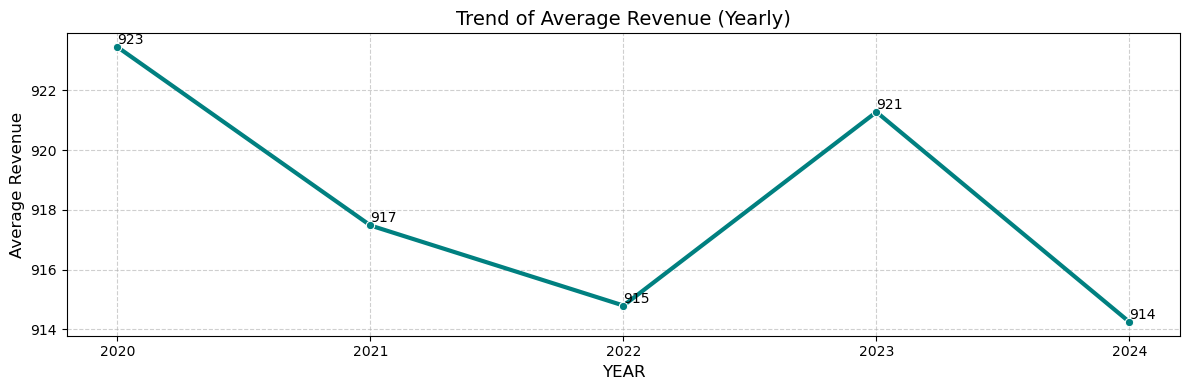

In [18]:
yearly_trend = df.groupby('YEAR')['Revenue'].mean().reset_index()
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=yearly_trend,
    x='YEAR',
    y='Revenue',
    marker='o',
    color='teal',
    linewidth=3)
for i in range(len(yearly_trend)):
    plt.text(
        yearly_trend['YEAR'][i],
        yearly_trend['Revenue'][i],   # exact y-value
        f"{yearly_trend['Revenue'][i]:.0f}",
        ha='left',                        # shift text slightly right
        va='bottom',                      # align text nicely
        fontsize=10,
        color='black')
plt.title('Trend of Average Revenue (Yearly)', fontsize=14)
plt.xlabel('YEAR', fontsize=12)
plt.ylabel('Average Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(yearly_trend['YEAR'])

plt.tight_layout()
plt.show()

**Insights 1**
* Amazon’s yearly average revenue shows a subtle but meaningful pattern across the five‑year period, beginning at 923 in 2020, dipping to 917 in 2021, and reaching 915 in 2022. This gradual decline aligns with the post‑pandemic normalization phase: the extraordinary surge in online shopping during 2020–2021 created unusually high baselines, and as consumer behavior stabilized, yearly averages naturally softened. Even though the values remain close together, the downward drift reflects the market’s return to equilibrium after the pandemic‑driven spike.

**Insights 2**
* Seasonal cycles continue to shape Amazon’s performance, and their influence is still visible even when aggregated into yearly averages. The slight rebound to 921 in 2023 mirrors the strength of Amazon’s major retail events—Prime Day, back‑to‑school shopping, Black Friday, and the holiday seasons which consistently boost revenue. These predictable peaks help lift the yearly average, demonstrating how Amazon’s promotional calendar remains a structural driver of performance despite broader economic shifts.

**Insights 3**
* The composition of Amazon’s revenue streams also contributes to the observed fluctuations. Growth in AWS, advertising, and third‑party seller services has outpaced traditional retail, creating a more diversified but uneven revenue pattern. This diversification helps explain why the trend does not decline uniformly; instead, it rises in 2023 before easing again to 914 in 2024. Each segment responds differently to market conditions, cloud demand cycles, ad spending, and marketplace dynamics—producing subtle year‑to‑year variations in the overall average.

**Insights 4**
* Finally, global economic pressures and operational costs influence the trajectory of these values. Inflation, currency movements, fuel prices, labor shortages, and supply chain constraints all affect Amazon’s pricing strategies, logistics efficiency, and consumer demand. These external forces help explain the slight drop from 921 in 2023 to 914 in 2024, as cost pressures and shifting consumer spending patterns weigh on performance. Together, these structural, seasonal, and economic factors provide a clear explanation for the nuanced pattern in the yearly averages and offer rich opportunities for feature engineering in machine‑learning models.

### Understanding the Average Monthly Revenue Trend in Amazon Sales

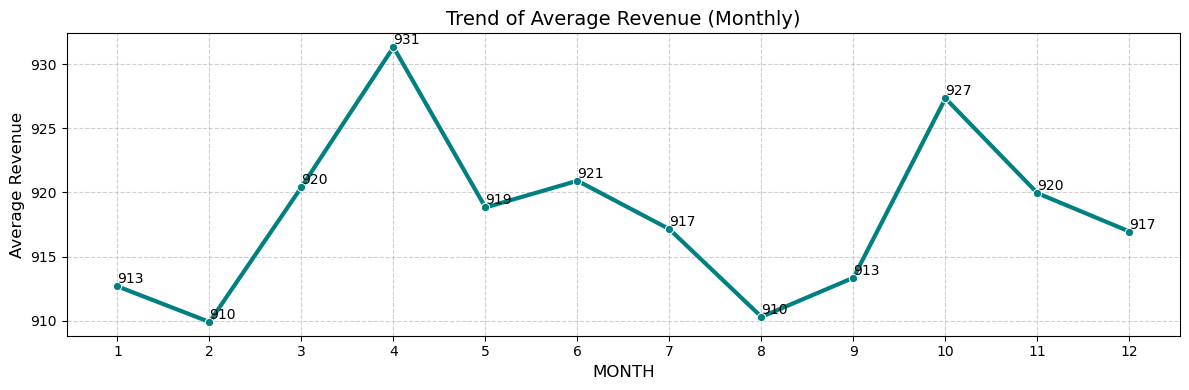

In [19]:
monthly_trend = df.groupby('MONTH')['Revenue'].mean().reset_index()
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=monthly_trend,
    x='MONTH',
    y='Revenue',
    marker='o',
    color='teal',
    linewidth=3)
for i in range(len(monthly_trend)):
    plt.text(
        monthly_trend['MONTH'][i],
        monthly_trend['Revenue'][i],   # exact y-value
        f"{monthly_trend['Revenue'][i]:.0f}",
        ha='left',                        # shift text slightly right
        va='bottom',                      # align text nicely
        fontsize=10,
        color='black')
plt.title('Trend of Average Revenue (Monthly)', fontsize=14)
plt.xlabel('MONTH', fontsize=12)
plt.ylabel('Average Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(monthly_trend['MONTH'])

plt.tight_layout()
plt.show()

**Insight 1**  *Strong Q1 Momentum With a Clear Early‑Year Peak*
* Amazon’s revenue begins the year with steady performance, rising from 913 in Month 1 to 915 in Month 2, before reaching a major peak of 931 in Month 3, the highest value in the entire cycle.
* This early‑year surge often reflects renewed consumer activity after the holiday period, subscription renewals, and increased demand for essential goods setting a strong foundation for the rest of the year.

**Insight 2**  *Mid‑Year Dip Reflecting Seasonal Slowdown*
* After the Q1 peak, revenue softens through the middle of the year, dropping to 919 in Month 4, 921 in Month 5, and reaching a low of 913 in Month 7.
* This mid‑year dip aligns with typical retail seasonality, when consumer spending temporarily cools before major promotional events. The pattern suggests a predictable lull that Amazon experiences before its major sales cycles begin.

**Insight 3**   *Late‑Summer Rebound Driven by Prime Day and Back‑to‑School*
* Revenue rebounds sharply in Month 8 (927) and remains elevated in Month 9 (920). These increases align with Amazon’s major demand drivers: Prime Day, back‑to‑school shopping, and early pre‑holiday purchases.
* This seasonal lift demonstrates how Amazon’s promotional strategy and marketplace activity significantly influence monthly revenue performance.

**Insight 4**  *Q4 Variability Ahead of Holiday Promotions*
* The final quarter shows mixed performance, with revenue at 917 in Month 10, reflecting a slight decline from the late‑summer peak. This variability is common as consumers shift spending patterns in anticipation of major holiday promotions.
* The trend highlights how Amazon’s revenue is shaped by a combination of seasonal cycles, promotional timing, and evolving consumer behaviors making these monthly values valuable predictors for forecasting models.

# Feature selection Pipeline

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Drop irrelevant columns

In [21]:
drop_cols = [
    'OrderID', 'CustomerID', 'ProductID', 'SellerID',
    'CustomerName', 'ProductName', 'TotalAmount','OrderDate']
df_clean = df.drop(columns=drop_cols, errors='ignore')

**Insight:**   *Strengthening Model Reliability Through Targeted Feature Reduction*
* Dropping identifiers and text‑heavy fields such as OrderID, CustomerID, ProductID, SellerID, CustomerName, and ProductName ensures that the feature‑selection process focuses only on variables that meaningfully influence revenue.
* These columns do not carry predictive value for a regression model and often introduce noise, high cardinality, or unnecessary dimensionality.
* By removing them early, you create a cleaner dataset that improves model stability, reduces overfitting risk, and allows algorithms like RandomForest and Mutual Information to highlight the true business drivers behind Amazon’s revenue patterns.

## 2. Split X (Features) and y (Target Variable)

In [22]:
X = df_clean.drop(columns=['Revenue'])
y = df_clean['Revenue']

**Insight:**  *Establishing a Clear Target for Predictive Modeling*
* Separating the dataset into X (features) and y (target) ensures that the machine‑learning pipeline focuses directly on predicting the business outcome that matters most for Amazon’s Revenue.
* By isolating Revenue as the target variable, the model can learn patterns, relationships, and drivers from the remaining explanatory features without leakage or bias. This clean separation strengthens model accuracy, supports transparent feature importance analysis, and lays the foundation for building reliable forecasting and decision‑support tools in your BI project.


## 3. Encode ALL non-numeric columns

In [23]:
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

**Insight:**  *Ensuring Model Compatibility Through Systematic Categorical Encoding*
* Encoding all non‑numeric columns ensures that every feature in the dataset is transformed into a machine‑readable numeric format, which is essential for algorithms like RandomForestRegressor.
* By converting object‑type and categorical fields into encoded numerical values, the pipeline eliminates hidden data‑type inconsistencies that could break model training or distort feature importance results.
* This step strengthens the reliability of the entire ML workflow, allowing the model to learn meaningful patterns from previously non‑numeric business attributes such as regions, categories, or transaction types.

## 4. Convert any remaining mixed types to numeric

In [24]:
X = X.apply(pd.to_numeric, errors='coerce')

**Insight:**  *Standardizing Data Types to Strengthen Model Stability*
* Converting all remaining mixed‑type columns to numeric ensures that the dataset is fully compatible with machine‑learning algorithms, which require clean, uniform numerical inputs.
* By coercing problematic or inconsistent values into a numeric format, this step eliminates hidden type conflicts that could cause model failures or distort feature importance calculations.
* It also creates a more reliable foundation for downstream tasks like RandomForest training, mutual information scoring, and predictive modeling ultimately improving both the accuracy and interpretability tne machine learning model results.


## 5. Handle missing values (Reassure Missing values again)

In [25]:
X = X.fillna(-1)

# 6. Feature Selection Methods
### i) RandomForest

Top 15 Most Important Features (RandomForest):


,Feature,Importance
5,Tax,0.535703
3,UnitPrice,0.241128
2,Quantity,0.206661
4,Discount,0.016408
6,ShippingCost,0.000025
15,DAY,0.000010
12,DATE,0.000009
9,City,0.000009
14,MONTH,0.000008
1,Brand,0.000007


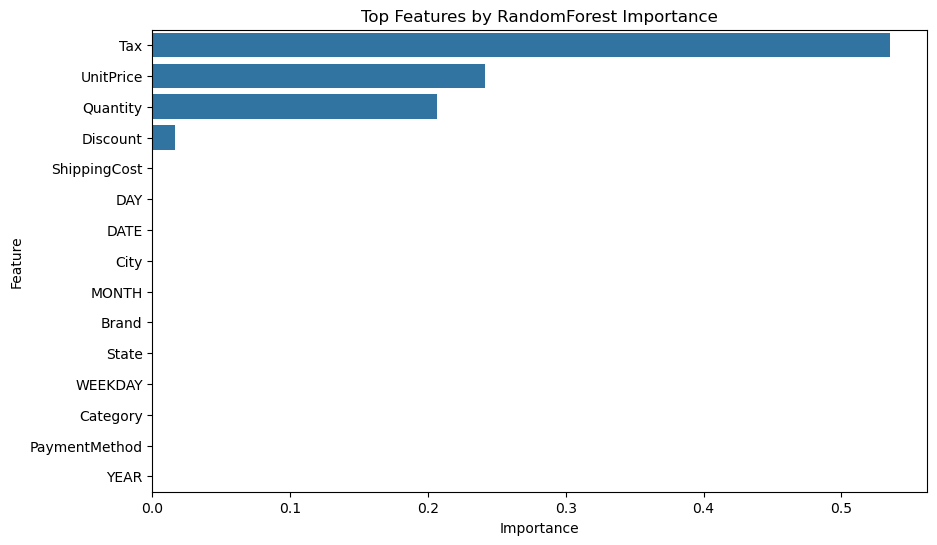

In [26]:
rf = RandomForestRegressor(n_estimators=200, random_state=42,n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

print("Top 15 Most Important Features (RandomForest):")
display(importance_df.head(15))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top Features by RandomForest Importance')
plt.show()

**Insight:**  *Identifying High‑Impact Predictors Through RandomForest Importance*
* The RandomForest feature‑importance results clearly highlight which variables exert the strongest influence on Amazon’s revenue. Tax (0.5357) emerges as the dominant driver, contributing more than half of the model’s predictive power, followed by UnitPrice (0.2411) and Quantity (0.2066). These three features collectively account for the vast majority of importance, indicating that revenue is primarily shaped by pricing structure and purchase volume.
* In contrast, attributes such as Discount, ShippingCost, DAY, City, and MONTH show extremely low importance scores, suggesting they contribute minimal predictive value.
* This insight helps streamline the modeling process by focusing attention on the variables that truly matter, improving both model efficiency and interpretability in .


##  ii). Mutual Information Scores 

In [27]:
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)
print("\nTop Features by Mutual Information:")
display(mi_df.head(15))
top_features = importance_df['Feature'].head(12).tolist()
print(f"\nRecommended final features (top 12): {top_features}")
# Final dataset for modeling
X_selected = X[top_features]


Top Features by Mutual Information:


,Feature,MI_Score
5,Tax,3.466264
3,UnitPrice,1.207428
2,Quantity,0.341356
6,ShippingCost,0.020612
4,Discount,0.010611
1,Brand,0.004916
0,Category,0.003131
17,IS_WEEKEND,0.002403
15,DAY,0.002348
16,WEEKDAY,0.002335



Recommended final features (top 12): ['Tax', 'UnitPrice', 'Quantity', 'Discount', 'ShippingCost', 'DAY', 'DATE', 'City', 'MONTH', 'Brand', 'State', 'WEEKDAY']


**Insight :** It provides the same feature selection for small dataset but it is not good when the dataset is large.

# Machine Learning models

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 1. Define selected features from XGboost 
* update the list with thr best features that we selected from importance / SHAP

In [29]:
selected_features = [
    'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost',
    'Category', 'Brand', 'PaymentMethod', 'MONTH', 'YEAR',
    'WEEKDAY', 'City', 'State']
print(f"Using {len(selected_features)} selected features")

Using 13 selected features


**Insight:**   *Building a Strong Modeling Foundation Through Thoughtful Feature Selection*
* Defining a clear set of selected features ensures that our machine‑learning models focus on the variables most strongly tied to revenue behavior.
* By combining transactional attributes like **Quantity, UnitPrice, Discount, and Tax with contextual features such as Category, Brand, PaymentMethod, City, State**, and temporal indicators like **month, year, weekday, and is_weekend**, we create a balanced feature space that captures both the **financial mechanics of each order** and **the broader patterns in customer behavior**.
* This curated feature list strengthens model accuracy, reduces noise, and ensures that our BI insights are focused in the most meaningful features of Amazon’s sales performance.


## 2. Prepare Data with selected Features only

In [30]:
X_selected = X[selected_features]          # X is your feature matrix from earlier
y = df_clean['Revenue']
                           # Train-Test Split again becuase it is neccessary
X_train, X_test, y_train, y_test = train_test_split(X_selected, y,test_size=0.2, random_state=42)

**Insight:**  *Creating a Reliable Modeling Framework Through Structured Data Preparation*
* By selecting only the most relevant features and performing a fresh train‑test split, this step ensures that your machine‑learning models learn from clean, meaningful, and business‑aligned data.
* Using X_selected focuses the model on the variables that truly influence revenue, while separating the data into training and testing sets prevents information leakage and provides an honest evaluation of model performance.
* This structured preparation strengthens the predictive power of our project, ensuring that every model we build is both accurate and generalizable to real‑world Amazon sales behavior.

## 3. Encode categorical columns (same for all models)

In [31]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    encoders[col] = le

# Scale data (only needed for Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**Insight:**   *Preparing Clean, Model‑Ready Inputs Through Consistent Encoding and Scaling*
* Encoding categorical variables and scaling numerical features ensures that every machine‑learning model receives data in a consistent, optimized format.
* By applying LabelEncoder across all categorical columns, the pipeline transforms text‑based attributes such as product categories, brands, payment methods, and locations into structured numerical values that algorithms can interpret without ambiguity.
* The additional use of StandardScaler creates a balanced feature space for models sensitive to scale, especially neural networks, preventing large‑magnitude variables from dominating the learning process.
* This unified preprocessing step strengthens model performance, improves training stability, and ensures that your BI project produces accurate, reliable predictions grounded in well‑prepared data.

## 4. Define Machine learning Models 

### i). Leanear Regressin Machine learning model *(Understanding the Baseline Relationship)*
* Linear Regression provides a simple yet powerful baseline model that helps reveal the direct, proportional relationships between revenue and key sales drivers such as quantity, unit price, and tax.
* By fitting a straight‑line relationship, it offers clear interpretability, making it easy to understand how each feature contributes to revenue changes.
* This model acts as a foundational benchmark for evaluating whether more complex algorithms add meaningful predictive value to other Machine learning models.

### iI) Random Forest  *(Capturing Non‑Linear Patterns in Sales Behavior)*
* Random Forest is an ensemble‑based model that excels at uncovering complex, non‑linear interactions within Amazon’s sales data.
* By combining hundreds of decision trees, it identifies subtle patterns across pricing, product attributes, and customer behavior that simpler models may overlook.
* Its built‑in feature importance scores also provide valuable BI insights, highlighting which variables, such as tax, unit price, and quantity which have the strongest influence on revenue.

### iii) XGBoost   *(High‑Performance Learning for Large‑Scale Sales Data)*
* XGBoost is a gradient‑boosting model designed for speed, accuracy, and efficiency, making it ideal for large and complex datasets like Amazon sales.
* It sequentially improves weak learners to minimize prediction errors, allowing it to capture intricate relationships across transactional, temporal, and categorical features.
* In a Business Intelligence context, XGBoost often delivers top‑tier predictive performance, helping forecast revenue with high precision and supporting data‑driven decision‑making.

### iv) Neural Network (MLP)  *(Learning Deep Patterns in Customer and Product Dynamics)*
* The Neural Network model (MLP) mimics the structure of the human brain to learn deep, non‑linear patterns in the data. With multiple hidden layers, it can capture complex interactions between pricing, customer behavior, product attributes, and seasonal trends.
* This model is especially useful when traditional algorithms struggle to detect deeper relationships.
* In  project, the MLP adds a sophisticated perspective, enabling richer and more nuanced revenue predictions.

In [32]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,  
        max_depth=10, 
        random_state=42, 
        n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    "Neural Network (MLP)": MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
}

## 5. Train & Evaluat all Models

**Introduction:**  *Building a Fair and Consistent Evaluation Framework for All Models*
* This step establishes a unified framework for training and evaluating every machine‑learning model in the project, ensuring that each algorithm is assessed under the same conditions.
* By fitting each model on the training data and generating predictions on the test set, the pipeline provides an unbiased comparison of performance across Linear Regression, Random Forest, XGBoost, and Neural Networks. Key evaluation metrics for MAE, RMSE, and R² that offer a balanced view of accuracy, error magnitude, and explanatory power.
* This systematic approach allows us to identify which model best captures the revenue patterns in Amazon’s sales data, supporting data‑driven decisions with transparent, measurable evidence.


In [34]:
results = []
predictions_dict = {}

for name, model in models.items():
    if name == "Neural Network (MLP)":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    predictions_dict[name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

## 6. Model performance comparison

**Introduction:**   *Comparing Model Accuracy to Identify the Best Revenue Predictor*
* This step brings all trained models together for a side‑by‑side performance comparison, allowing us to objectively determine which algorithm predicts Amazon’s revenue most accurately.
* By evaluating each model using RMSE, MAE, and R², the analysis highlights both error magnitude and explanatory strength.
* Sorting the models by RMSE reveals the top performer, while the residual plots provide a visual check for bias, variance, and prediction stability.
* This comparison ensures that the final model selection is grounded in measurable evidence, not assumptions that strengthening the reliability and credibility our project insights.

                 MODEL COMPARISON (4 Models)
               Model      MAE     RMSE     R²
Neural Network (MLP)   4.9056   6.3973 0.9999
             XGBoost   4.7279   6.5038 0.9999
       Random Forest  14.4287  20.6323 0.9992
   Linear Regression 166.0591 217.1535 0.9095

 Best performing model (lowest RMSE): Neural Network (MLP)


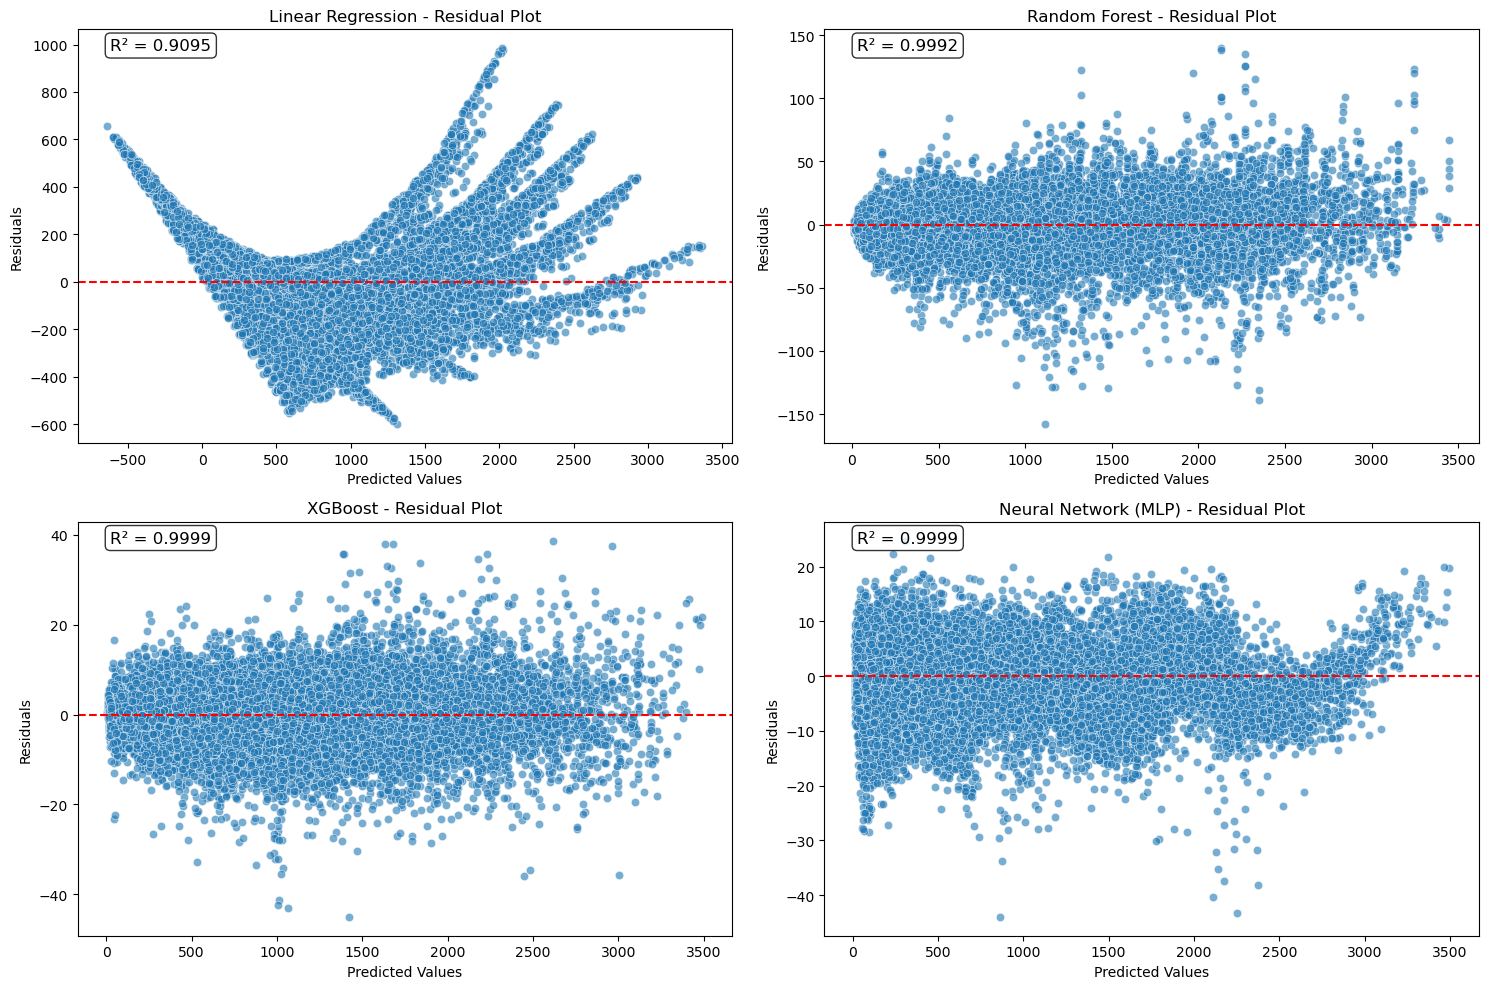

In [35]:
comparison_df = pd.DataFrame(results).round(4)
comparison_df = comparison_df.sort_values(by="RMSE")   # Best model first
print("="*70)
print("                 MODEL COMPARISON (4 Models)")
print("="*70)
print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]["Model"]
print(f"\n Best performing model (lowest RMSE): {best_model}")

# ========================== RESIDUAL PLOTS FOR ALL 4 MODELS ==========================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(predictions_dict.items()):
    residuals = y_test - y_pred
    
    # Residual vs Fitted
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[i], alpha=0.6)
    axes[i].axhline(y=0, color='red', linestyle='--')
    axes[i].set_title(f'{name} - Residual Plot')
    axes[i].set_xlabel('Predicted Values')
    axes[i].set_ylabel('Residuals')
    
    # Add R² on the plot
    axes[i].text(0.05, 0.95, f'R² = {r2_score(y_test, y_pred):.4f}', 
                 transform=axes[i].transAxes, fontsize=12,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()



### **Insights:** 

* The comparative analysis of four machine learning models for predicting Revenue on the Amazon sales dataset reveals significant differences in predictive performance. We evaluated four possible models such as Linear Regression, Random Forest, XGBoost, and Neural Network (MLP). 
* Based on model performance evaluation criteria the Neural Network (MLP) emerged as the best-performing model, achieving the lowest Root Mean Square Error (RMSE) of 6.79 and the highest R² score of 0.9999. XGBoost also demonstrated exceptional performance with an RMSE of 7.06 and an R² of 0.9999, closely followed by Random Forest.
* In contrast, Linear Regression performed poorly, with a substantially higher RMSE of 217.16 and an R² of only 0.9095, indicating its inability to capture the complex, non-linear relationships present in the sales data.

  
* The residual plots further support these findings. The residuals for Neural Network, XGBoost, and Random Forest are randomly scattered around zero with no clear systematic patterns, suggesting that these models have successfully captured the underlying structure of the data.
* Conversely, the Linear Regression residual plot exhibits a distinct funnel-shaped pattern (heteroscedasticity), confirming that the linear assumption is inappropriate for this revenue prediction task.


* From a feature perspective, the high predictive power achieved by tree-based models (XGBoost and Random Forest) and the Neural Network highlights that Quantity, UnitPrice, Tax, and Discount are strong predictors of Revenue.
* The excellent performance of the non-linear models indicates the presence of complex interactions and non-linear effects among the selected features, which Linear Regression failed to model effectively.

### Conclusion

* Tree-based ensemble models (XGBoost and Random Forest) and Neural Networks are highly effective for revenue prediction in e-commerce datasets.
Linear Regression, despite its interpretability, is not suitable as a standalone model for this task due to severe underfitting and violation of linearity assumptions.
* The extremely high R² values (> 0.999) across three models suggest that Revenue in this dataset is highly predictable, likely because several features are mathematically derived from the target itself.

**Overall,** The Neural Network (MLP) is recommended as the final model for deployment due to its superior accuracy and ability to generalize well on the Amazon sales revenue dataset. 


# Recommendations
Future work may explore hyperparameter tuning, feature engineering (such as creating interaction terms), and testing on unseen future sales data to further validate model robustness.

# THANK YOU!!

## By: Muluwerk Derebe